In [8]:
import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1", render_mode="rgb_array",is_slippery = False)

EPISODES = 5000 # number of times the agent gets to train
MAX_STEPS = 100 #the number of time an agent gets to make a move in a single episode

LEARNING_RATE = 0.81 #how much update should be included
GAMMA = 0.96 #how much weight to attacj=h on future rewards

# threshold until agent starts making its own decesions based on the Q-table

EPSILON_START = 0.9
MIN_EPSILON = 0.01
ACTIONS = env.action_space.n
STATES = env.observation_space.n

Q_TABLE = np.zeros((STATES,ACTIONS))
epsilon = EPSILON_START
rewards = []
for episode in range(EPISODES):

  # at the begginning of each episode agent is at the same position
  state = env.reset()[0]


  # MOVING THROUGH THE ENVIRONMENT

  for _ in range(MAX_STEPS):

    # select action

    if np.random.uniform(0,1) < epsilon:
      action = env.action_space.sample() #select a random action

    else:
      action = np.argmax(Q_TABLE[state, :]) #select best action

    # agent takes an action

    next_state, reward, terminated, truncated, _ = env.step(action)



    # Updating Q_Table

    Q_TABLE[state, action] = Q_TABLE[state, action] + LEARNING_RATE * (reward + GAMMA * np.max(Q_TABLE[next_state, :]) - Q_TABLE[state, action])

    state = next_state #update agents position

    if terminated or truncated:
      rewards.append(reward)
      epsilon = max(0.01,epsilon-0.001)
      break # when goal is reached or when hole is encountered move


average_rewards = sum(rewards) / len(rewards)
print(average_rewards)







0.8976


# Visualzing Training Agent

Starting simulation of trained agent...



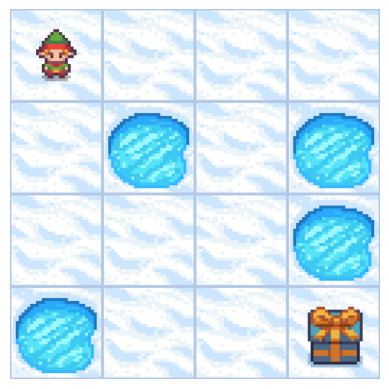

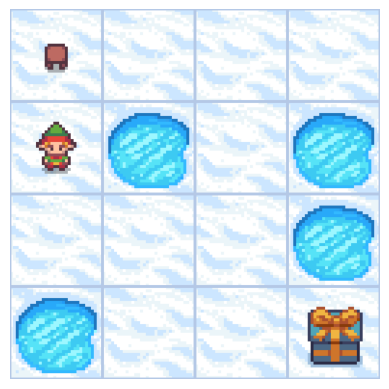

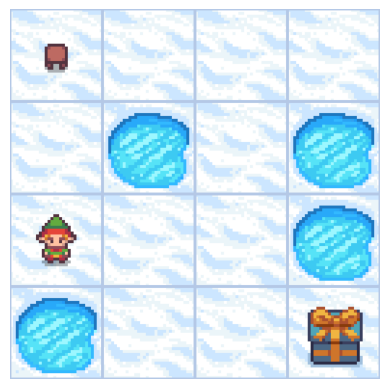

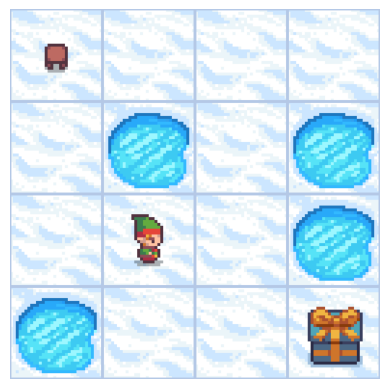

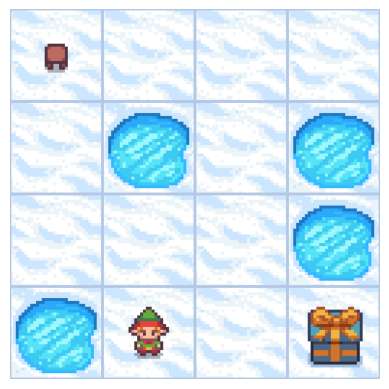

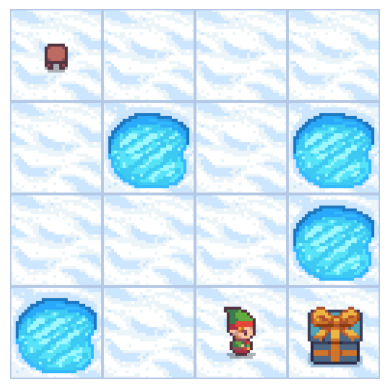

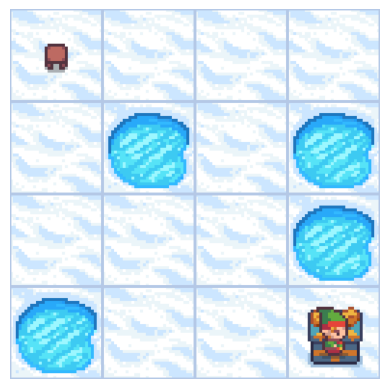

Episode finished after 6 steps. Reward: 1. Terminated: True. Truncated: False.


In [9]:
import matplotlib.pyplot as plt

def visualize():
  plt.imshow(env.render())
  plt.axis('off')
  plt.show()

# agent has a maximum of 100 steps to complete game
state,_= env.reset()


print("Starting simulation of trained agent...\n")

visualize() # Call visualize() to display the initial state


for step in range(MAX_STEPS):


  #select action from learned Q-table


  action = np.argmax(Q_TABLE[state,:])#take action with best reward

  #take action

  next_state,reward,terminated,truncated,_ = env.step(action)
  visualize() # Call visualize() to display the updated state

  state = next_state #move to current state

  #if reached goal print reward
  if terminated or truncated:
    print(f"Episode finished after {step+1} steps. Reward: {reward}. Terminated: {terminated}. Truncated: {truncated}.")

    break